In [10]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [11]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

In [12]:
train_images = train_images / 255.0
test_images = test_images / 255.0

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

In [13]:
model = models.Sequential()

model.add(layers.Input(shape=(32,32,3)))

model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_images, train_labels,
    epochs=15,
    validation_data=(test_images, test_labels)
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 42ms/step - accuracy: 0.4417 - loss: 1.5314 - val_accuracy: 0.5463 - val_loss: 1.2538
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step - accuracy: 0.5850 - loss: 1.1746 - val_accuracy: 0.6268 - val_loss: 1.0608
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6414 - loss: 1.0179 - val_accuracy: 0.6523 - val_loss: 1.0014
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6774 - loss: 0.9239 - val_accuracy: 0.6597 - val_loss: 0.9752
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - accuracy: 0.6999 - loss: 0.8587 - val_accuracy: 0.6832 - val_loss: 0.9223
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.7208 - loss: 0.8043 - val_accuracy: 0.6985 - val_loss: 0.8695
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.7349 - loss: 0.7553 - val_accuracy: 0.6972 - val_loss: 0.8825
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.7487 -

In [16]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("\n✅ Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7123 - loss: 0.9134

✅ Test Accuracy: 0.7123000025749207


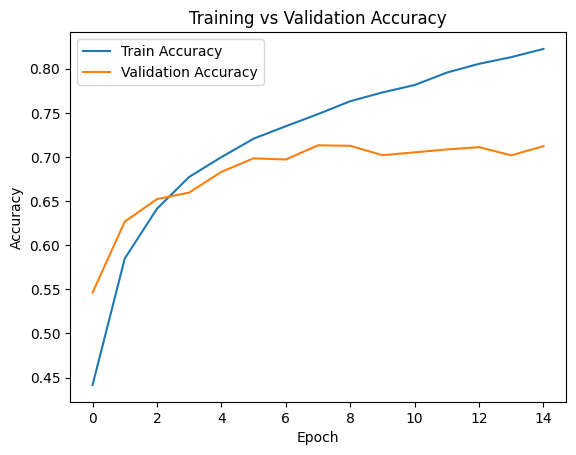

In [17]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [18]:
model.save("image_classifier_model.h5")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [19]:
from google.colab import files
files.download("image_classifier_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>